# Experiment A - MPJPE & PCK vs network_period

Loads all generated CSVs across all sequences and computes:
- per-sequence MPJPE
- dataset-level MPJPE (weighted by number of frames)
- PCK vs network_period curve (using reference distance between joints 1 and 5)
Outputs:

*MPJPE:*
- `results/summary/mpjpe_per_sequence.csv`
- `results/summary/mpjpe_table.csv`
- `plots/mpjpe_vs_network_period.png`
- `plots/mpjpe_vs_detection_rate.png`

*PCK:*
- `results/summary/pck_per_sequence.csv`
- `results/summary/pck_table.csv`
- `plots/pck_vs_network_period_*.png` (one per threshold)
- `plots/pck_comparison_all_thresholds.png`



In [21]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

from datasets.utils import constants as ds_constants, parsing as ds_parsing

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [ ]:
EXP_DIR = Path('/workspace/moveEnetFlow/experiments/expA_accuracy_vs_network_period')
RAW_DIR = EXP_DIR /'dhp19_full_test' /'results' / 'raw'
SUMMARY_DIR = EXP_DIR /'dhp19_full_test'/ 'results' / 'summary'
PLOTS_DIR = EXP_DIR /'dhp19_full_test' / 'plots'
DATASET = 'dhp19'  # allowed: eh36m, dhp19

# Must match the --data_root used in run_experiment_a.sh
DATA_ROOT = Path('/data/dhp19_testing_set_S13toS17')

SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Network periods to test (must match the PERIODS array in run_experiment_a.sh)
period_tokens = ["0.01", "0.02", "0.05", "0.1", "0.2", "0.5"]
period_values = [float(x) for x in period_tokens]
# period_token_to_val = {t: v for t, v in zip(period_tokens, period_values)}

# PCK thresholds to evaluate
pck_thresholds = [0.1, 0.2, 0.4, 0.6]

print('DATA_ROOT:', DATA_ROOT)
print('RAW_DIR:', RAW_DIR)
print('Network periods:', period_values)
print('PCK Thresholds:', pck_thresholds)

DATA_ROOT: /data/dhp19_testing_set_S13toS17
RAW_DIR: /workspace/moveEnetFlow/experiments/expA_accuracy_vs_network_period/dhp19_full_test/results/raw
Periods: [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
PCK Thresholds: [0.1, 0.2, 0.4, 0.6]


In [29]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'

# print('Joints:', joint_names)

# Reference joints for PCK normalization
REF_JOINT_1 = 1  # First reference joint (e.g., right shoulder)
REF_JOINT_2 = 5  # Second reference joint (e.g., left hip)

print(f'Reference distance computed between joint {REF_JOINT_1} ({joint_names[REF_JOINT_1]}) and joint {REF_JOINT_2} ({joint_names[REF_JOINT_2]})')


def period_to_tag(period_token: str) -> str:
    """Convert period string to filename-safe tag (e.g., '0.01' -> '0p01')"""
    return period_token.replace('.', 'p')

def tag_to_period(tag: str) -> float:
    """Convert filename tag back to period value (e.g., '0p01' -> 0.01)"""
    return float(tag.replace('p', '.'))

def period_tag_from_folder(csv_path: Path):
    """
    Extract fp and np tags from folder structure:

        RAW_DIR/fp_0p01/np_0p1/file.csv

    Returns:
        np_tag, fp_tag
    """
    np_folder = csv_path.parent.name          # e.g. np_0p1
    fp_folder = csv_path.parent.parent.name   # e.g. fp_0p01

    if not np_folder.startswith("np_"):
        raise ValueError(f"Unexpected network-period folder: {np_folder}")

    if not fp_folder.startswith("fp_"):
        raise ValueError(f"Unexpected flow-period folder: {fp_folder}")

    np_tag = np_folder.replace("np_", "")
    fp_tag = fp_folder.replace("fp_", "")

    return np_tag, fp_tag

def load_pred_eval_csv(csv_path: Path):
    """Load prediction CSV file and extract timestamps + joint coordinates.
    
    CSV format (evaluation format): [timestamp, latency, joint0_x, joint0_y, ..., joint12_x, joint12_y, velocities_if_requested]
    Returns: (timestamps, joints_array[N_frames, 13_joints, 2_coords])
    """
    arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')
    ts = arr[:, 0]
    joints = arr[:, 2:28].reshape(-1, 13, 2)
    return ts, joints

def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray):
    """Interpolate ground truth skeleton data to match prediction timestamps.
    
    GT data comes at different sample rates than predictions, so we use linear 
    interpolation to align them for proper evaluation metrics calculation.
    """
    ts_gt_raw = np.asarray(gt_data['ts'])
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))
    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)
    for j, joint in enumerate(joint_names):
        x_raw = gt_data[joint][:, 0]
        y_raw = gt_data[joint][:, 1]
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)
    return joints_gt

def extract_metadata_from_name(csv_path: Path, dataset: str = DATASET):
    """
    Parse experiment filename metadata.

    Supported dhp19 examples:
        S13_1_1__ch2dvs_moveenet_ofk_np_0p1_fp_0p01
        S13_1_1__ch2dvs_moveenet_only_np_0p1_fp_0p01

    Supported eh36m examples:
        cam2_S11_Directions__ch0dvs_moveenet_ofk_np_0p01_fp_0p005
        cam2_S11_Directions__ch0dvs_moveenet_only_np_0p01_fp_0p005

    Returns:
        sequence_key, method_name, network_period_s, flow_period_s
    """

    if dataset not in {"dhp19", "eh36m"}:
        raise ValueError(f"Unknown dataset: {dataset}. Expected 'dhp19' or 'eh36m'.")

    name = Path(csv_path).name.strip()

    # Allow both filenames with and without .csv
    pattern = (
        r"(?P<sequence_base>.+?)__"
        r"(?P<channel>ch\d+dvs)_"
        r"(?P<method>moveenet_ofk|moveenet_only)_"
        r"np_(?P<network_period>\d+p\d+|\d+)_"
        r"fp_(?P<flow_period>\d+p\d+|\d+)"
        r"(?:\.csv)?$"
    )

    m = re.fullmatch(pattern, name)

    if not m:
        raise ValueError(
            f"Unrecognized filename format for dataset '{dataset}': {name}"
        )

    sequence_base = m.group("sequence_base")
    channel = m.group("channel")
    method_key = m.group("method")
    np_tag = m.group("network_period")
    fp_tag = m.group("flow_period")

    sequence_key = f"{sequence_base}__{channel}"

    if method_key == "moveenet_ofk":
        method_name = "MoveEnet + OFK"
    elif method_key == "moveenet_only":
        method_name = "MoveEnet only"
    else:
        raise ValueError(f"Unknown method: {method_key}")

    network_period_s = tag_to_period(np_tag)
    flow_period_s = tag_to_period(fp_tag)

    return sequence_key, method_name, network_period_s, flow_period_s

def gt_path_from_seq_key(seq_key: str, dataset: str = DATASET) -> Path:
    """
    Construct ground truth skeleton file path from sequence key.

    Expected seq_key examples:
        dhp19: S13_1_1__ch2dvs
        dhp19: S13_1_1__ch3dvs
        eh36m: cam2_S11_Directions__ch0dvs

    For dhp19:
        S13_1_1__ch2dvs -> DATA_ROOT / S13_1_1 / ch2GT200Hzskeleton / data.log
        S13_1_1__ch3dvs -> DATA_ROOT / S13_1_1 / ch3GT200Hzskeleton / data.log

    For eh36m:
        cam2_S11_Directions__ch0dvs -> DATA_ROOT / cam2_S11_Directions / ch0GT200Hzskeleton / data.log
    """

    if dataset not in {"dhp19", "eh36m"}:
        raise ValueError(f"Unknown dataset: {dataset}. Expected 'dhp19' or 'eh36m'.")

    parts = seq_key.split("__")

    channel = None
    sequence_parts = parts

    # If final part is ch0dvs, ch2dvs, ch3dvs, etc., extract it
    if parts and re.fullmatch(r"ch\d+dvs", parts[-1]):
        channel_dvs = parts[-1]          # e.g. ch2dvs
        channel = channel_dvs.replace("dvs", "")  # e.g. ch2
        sequence_parts = parts[:-1]

    # Reconstruct dataset-relative sequence path
    rel = Path(*sequence_parts)

    if dataset == "dhp19":
        if channel not in {"ch2", "ch3"}:
            raise ValueError(
                f"For dhp19, expected seq_key to end with '__ch2dvs' or '__ch3dvs'. "
                f"Got: {seq_key}"
            )
        gt_folder = f"{channel}GT200Hzskeleton"

    elif dataset == "eh36m":
        gt_folder = "ch0GT200Hzskeleton"

    return DATA_ROOT / rel / gt_folder / "data.log"


def calculate_pck(joints_pred: np.ndarray, joints_gt: np.ndarray, threshold: float) -> np.ndarray:
    """Calculate PCK for predictions vs ground truth.
    
    Args:
        joints_pred: [N_frames, 13_joints, 2_coords] predicted joint positions
        joints_gt: [N_frames, 13_joints, 2_coords] ground truth joint positions
        threshold: PCK threshold as fraction of reference distance
    
    Returns:
        pck: [N_frames, 13_joints] binary array (1 if error <= threshold * ref_dist, 0 otherwise)
    """
    # Compute Euclidean distance between predicted and ground truth
    err_dist = np.linalg.norm(joints_pred - joints_gt, axis=2)  # [N_frames, 13]
    
    # Reference distance per frame (distance between joint REF_JOINT_1 and REF_JOINT_2)
    ref_vec = joints_gt[:, REF_JOINT_2, :] - joints_gt[:, REF_JOINT_1, :]
    ref_dist = np.linalg.norm(ref_vec, axis=1)  # [N_frames]
    
    # Avoid division by zero
    ref_dist = np.maximum(ref_dist, 1e-6)
    
    # Compute PCK: 1 if error <= threshold * ref_dist, else 0
    pck = (err_dist <= threshold * ref_dist[:, np.newaxis]).astype(np.float32)
    
    return pck

Reference distance computed between joint 1 (shoulder_right) and joint 5 (hip_left)


In [24]:
csv_files = sorted(RAW_DIR.glob("fp_*/np_*/*.csv"))

print(f"Found {len(csv_files)} prediction CSV files")

if len(csv_files) == 0:
    raise RuntimeError(
        "No CSV files found. Run run_experiment_a.sh or run_experiment_a_pck.sh first."
    )


gt_cache = {}
rows = []

print("Processing CSV files and computing MPJPE + PCK...")

for idx, csv_path in enumerate(csv_files):
    if idx % 10 == 0:
        print(f"  [{idx}/{len(csv_files)}]")

    # Metadata from filename
    seq_key, method, network_period_s, flow_period_s = extract_metadata_from_name(
        csv_path,
        dataset=DATASET
    )

    # Metadata from folders
    np_folder_tag, fp_folder_tag = period_tag_from_folder(csv_path)

    network_period_from_folder = tag_to_period(np_folder_tag)
    flow_period_from_folder = tag_to_period(fp_folder_tag)

    # Safety checks: filename and folder must agree
    if not np.isclose(network_period_s, network_period_from_folder):
        raise ValueError(
            "Network period mismatch:\n"
            f"  CSV file: {csv_path.name} -> {network_period_s}\n"
            f"  Folder:   {csv_path.parent.name} -> {network_period_from_folder}\n"
            f"  Full path: {csv_path}"
        )

    if not np.isclose(flow_period_s, flow_period_from_folder):
        raise ValueError(
            "Flow period mismatch:\n"
            f"  CSV file: {csv_path.name} -> {flow_period_s}\n"
            f"  Folder:   {csv_path.parent.parent.name} -> {flow_period_from_folder}\n"
            f"  Full path: {csv_path}"
        )

    # Ground-truth path
    gt_path = gt_path_from_seq_key(seq_key, dataset=DATASET)

    if not gt_path.exists():
        print(f"Skipping missing GT: {gt_path}")
        continue

    # Load GT only once per sequence/channel
    if gt_path not in gt_cache:
        gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(
            gt_path,
            multi_channel=False
        )

    gt_data = gt_cache[gt_path]

    # Load predictions
    ts_pred, joints_pred = load_pred_eval_csv(csv_path)

    # Interpolate GT to prediction timestamps
    joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

    # MPJPE: Euclidean pixel error per sample and per joint
    err = np.linalg.norm(joints_pred - joints_gt, axis=2)  # shape: [N, 13]

    per_joint_err = err.mean(axis=0)
    mpjpe_px = float(err.mean())

    # PCK
    pck_results = {}

    for th in pck_thresholds:
        pck_binary = calculate_pck(joints_pred, joints_gt, th)  # shape: [N, 13]

        # Overall PCK
        pck_results[f"pck_{th:.1f}"] = float(pck_binary.mean() * 100.0)

        # Per-joint PCK
        for j, joint in enumerate(joint_names):
            pck_results[f"pck_{th:.1f}_{joint}"] = float(
                pck_binary[:, j].mean() * 100.0
            )

    n_samples = int(err.shape[0])

    rows.append({
        "sequence": seq_key,
        "method": method,
        "flow_period_s": flow_period_s,
        "network_period_s": network_period_s,
        "detection_rate_hz": 1.0 / network_period_s,
        "n_samples": n_samples,

        # Useful for weighted averages later
        "sum_err_px": float(err.sum()),
        "n_points": int(err.size),

        # Overall MPJPE
        "mpjpe_px": mpjpe_px,

        # Per-joint MPJPE
        **{
            f"mpjpe_{joint}": float(per_joint_err[i])
            for i, joint in enumerate(joint_names)
        },

        # PCK metrics
        **pck_results,
    })


if len(rows) == 0:
    raise RuntimeError("No valid rows were processed. Check GT paths and CSV files.")


df_seq = (
    pd.DataFrame(rows)
    .sort_values([
        "flow_period_s",
        "network_period_s",
        "sequence",
        "method"
    ])
    .reset_index(drop=True)
)

print(f"\nProcessed {len(df_seq)} sequence/method/period combinations")


# Compact display: overall metrics only
pck_cols = [f"pck_{th:.1f}" for th in pck_thresholds]

display_cols = [
    "sequence",
    "method",
    "flow_period_s",
    "network_period_s",
    "detection_rate_hz",
    "n_samples",
    "mpjpe_px",
] + pck_cols

visible_df = df_seq[display_cols].copy()

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
):
    display(visible_df)



Found 1920 prediction CSV files
Processing CSV files and computing MPJPE + PCK...
  [0/1920]
  [10/1920]
  [20/1920]
  [30/1920]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [40/1920]
  [50/1920]
  [60/1920]
  [70/1920]
  [80/1920]
  [90/1920]
  [100/1920]
  [110/1920]
  [120/1920]
  [130/1920]
  [140/1920]
  [150/1920]
  [160/1920]
  [170/1920]
  [180/1920]
  [190/1920]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
  [200/1920]
  [210/1920]
  [220/1920]
  [230/1920]
  [240/1920]
  [250/1920]
  [260/1920]
  [270/1920]
  [280/1920]
  [290/1920]
  [300/1920]
  [310/1920]
  [320/1920]
  [330/1920]
  [340/1920]
  [350/1920]
Skipping missing GT: /data/dhp19_testing_set_S13toS17/S14_1_1/ch2GT200Hzskeleton/data.log
Skipping mi

,sequence,method,flow_period_s,network_period_s,detection_rate_hz,n_samples,mpjpe_px,pck_0.1,pck_0.2,pck_0.4,pck_0.6
0,S13_1_1__ch2dvs,MoveEnet + OFK,0.005,0.01,100.0,4230,6.382178,33.749774,84.348065,99.734497,99.905437
1,S13_1_1__ch2dvs,MoveEnet only,0.005,0.01,100.0,4230,6.385648,33.749774,83.946174,99.716312,99.936354
2,S13_1_1__ch3dvs,MoveEnet + OFK,0.005,0.01,100.0,4127,5.703960,45.277813,93.660885,99.862069,99.992543
3,S13_1_1__ch3dvs,MoveEnet only,0.005,0.01,100.0,4127,5.788192,43.594715,92.749435,99.878848,99.985087
4,S13_1_2__ch2dvs,MoveEnet + OFK,0.005,0.01,100.0,4050,5.724873,51.042736,93.470085,98.514718,99.152899
5,S13_1_2__ch2dvs,MoveEnet only,0.005,0.01,100.0,4050,5.773834,50.501424,92.282999,98.638177,99.198478
6,S13_1_2__ch3dvs,MoveEnet + OFK,0.005,0.01,100.0,3873,5.549643,49.665335,96.792388,99.336630,99.904668
7,S13_1_2__ch3dvs,MoveEnet only,0.005,0.01,100.0,3873,5.608700,48.078412,96.204495,99.350536,99.898708
8,S13_1_3__ch2dvs,MoveEnet + OFK,0.005,0.01,100.0,3458,4.331022,69.086176,95.306313,98.818791,99.303734
9,S13_1_3__ch2dvs,MoveEnet only,0.005,0.01,100.0,3458,4.357786,67.884952,95.771235,98.912221,99.325979


In [25]:
if len(df_seq) == 0:
    raise RuntimeError("No valid sequence rows to aggregate.")


# Dataset-level aggregation per flow period + network period + method
# MPJPE is weighted by the total number of evaluated joint points.
agg = (
    df_seq
    .groupby(
        ["flow_period_s", "network_period_s", "detection_rate_hz", "method"],
        as_index=False
    )
    .agg(
        sum_err_px=("sum_err_px", "sum"),
        n_points=("n_points", "sum"),
        n_samples=("n_samples", "sum"),
    )
)

agg["mpjpe_px"] = agg["sum_err_px"] / agg["n_points"]

df_table = (
    agg
    .sort_values(["flow_period_s", "network_period_s", "method"])
    .reset_index(drop=True)
)


per_seq_path = SUMMARY_DIR / "mpjpe_per_sequence.csv"
table_path = SUMMARY_DIR / "mpjpe_table.csv"

df_seq.to_csv(per_seq_path, index=False)
df_table.to_csv(table_path, index=False)

print("Saved:", per_seq_path)
print("Saved:", table_path)


# Wide table for quick comparison
pivot = (
    df_table
    .pivot(
        index=["flow_period_s", "network_period_s", "detection_rate_hz"],
        columns="method",
        values="mpjpe_px"
    )
    .reset_index()
)

pivot.columns.name = None

display(pivot)


Saved: /workspace/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/summary/mpjpe_per_sequence.csv
Saved: /workspace/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/summary/mpjpe_table.csv


,flow_period_s,network_period_s,detection_rate_hz,MoveEnet + OFK,MoveEnet only
0,0.005,0.01,100.0,6.573682,6.630514
1,0.005,0.02,50.0,6.630707,6.644280
2,0.005,0.05,20.0,6.790445,6.711885
3,0.005,0.10,10.0,7.028880,6.881651
4,0.005,0.20,5.0,7.466906,7.304679
5,0.005,0.50,2.0,8.678987,8.628959
6,0.010,0.01,100.0,6.575375,6.630567
7,0.010,0.02,50.0,6.618129,6.644225
8,0.010,0.05,20.0,6.763457,6.711935
9,0.010,0.10,10.0,6.988247,6.881212


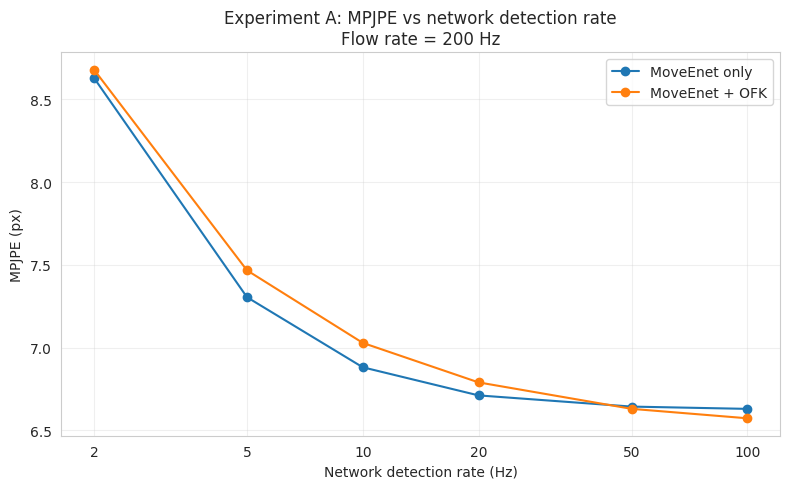

Saved: /workspace/moveEnetFlow/experiments/expA_accuracy_vs_network_period/plots/mpjpe_vs_detection_rate_hz_fp_0p005.png


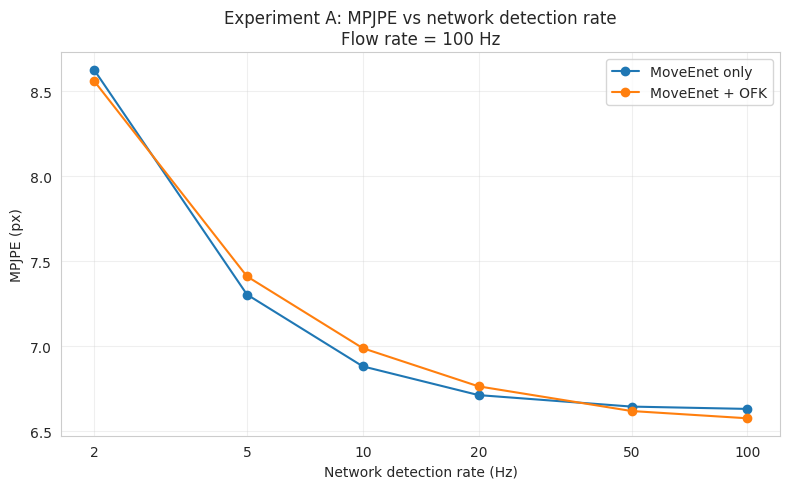

Saved: /workspace/moveEnetFlow/experiments/expA_accuracy_vs_network_period/plots/mpjpe_vs_detection_rate_hz_fp_0p01.png


In [28]:
import matplotlib.ticker as mticker


def period_to_tag(period_s: float) -> str:
    """
    Convert 0.01 -> 0p01, 0.005 -> 0p005, etc.
    Useful for filenames.
    """
    return f"{period_s:g}".replace(".", "p")


for flow_period_s in sorted(df_table["flow_period_s"].dropna().unique()):
    d_fp = df_table[df_table["flow_period_s"] == flow_period_s].copy()

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    for method in ["MoveEnet only", "MoveEnet + OFK"]:
        d = d_fp[d_fp["method"] == method].sort_values("detection_rate_hz")

        if len(d) == 0:
            continue

        plt.plot(
            d["detection_rate_hz"],
            d["mpjpe_px"],
            marker="o",
            label=method
        )

    # Use log scale, but force ticks at actual data points for this flow period
    plt.xscale("log")

    x_ticks = sorted(d_fp["detection_rate_hz"].dropna().unique())
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"{x:g}" for x in x_ticks])
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    flow_rate_hz = 1.0 / flow_period_s

    plt.xlabel("Network detection rate (Hz)")
    plt.ylabel("MPJPE (px)")
    plt.title(
        f"Experiment A: MPJPE vs network detection rate\n"
        f"Flow rate = {flow_rate_hz:g} Hz"
    )
    plt.grid(True, alpha=0.3)
    plt.legend()

    fp_tag = period_to_tag(flow_period_s)
    plot1 = PLOTS_DIR / f"mpjpe_vs_detection_rate_hz_fp_{fp_tag}.png"

    plt.tight_layout()
    plt.savefig(plot1, dpi=180)
    plt.show()

    print("Saved:", plot1)

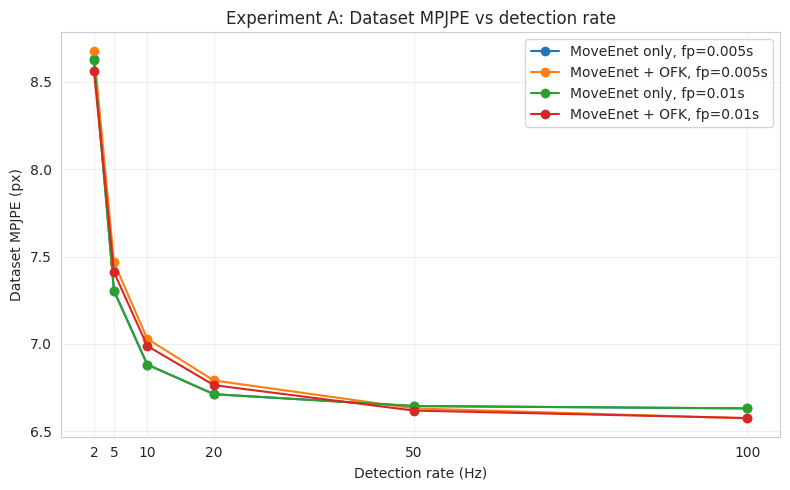

Saved: /workspace/moveEnetFlow/experiments/expA_accuracy_vs_network_period/plots/mpjpe_vs_detection_rate.png


In [27]:
import matplotlib.ticker as mticker

plt.figure(figsize=(8, 5))
ax = plt.gca()

for flow_period_s in sorted(df_table["flow_period_s"].unique()):
    for method in ["MoveEnet only", "MoveEnet + OFK"]:
        d = df_table[
            (df_table["method"] == method) &
            (df_table["flow_period_s"] == flow_period_s)
        ].sort_values("detection_rate_hz")

        if len(d) == 0:
            continue

        plt.plot(
            d["detection_rate_hz"],
            d["mpjpe_px"],
            marker="o",
            label=f"{method}, fp={flow_period_s:g}s"
        )

# Show one tick for each actual detection-rate value
x_ticks = sorted(df_table["detection_rate_hz"].dropna().unique())
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{x:g}" for x in x_ticks])

plt.xlabel("Detection rate (Hz)")
plt.ylabel("Dataset MPJPE (px)")
plt.title("Experiment A: Dataset MPJPE vs detection rate")
plt.grid(True, alpha=0.3)
plt.legend()

plot2 = PLOTS_DIR / "mpjpe_vs_detection_rate.png"
plt.tight_layout()
plt.savefig(plot2, dpi=180)
plt.show()

print("Saved:", plot2)
